# Analisis: Calidad del Aire vs Actividad Industrial
## Estacion Finanzas, Saltillo | Nov 2019 - Jun 2022

**Fuente 1:** SINAICA SEMARNAT: PM2.5, PM10, Ozono

**Fuente 2:** EMIM INEGI: Horas trabajadas Sector 336 Coahuila

**Universidad:** UAdeC - Seminario de Investigacion

### Archivos necesarios en la misma carpeta
```
sinaica_PM25_saltillo.xls
sinaica_PM10_saltillo.xls
sinaica_PMOZONO_saltillo.xls
tr_variable_subsector_entidad_mensual_2013_2023.csv
```

## Celda 1 - Instalar librerias
Ejecuta solo una vez.

In [ ]:
!pip install pandas numpy scipy scikit-learn matplotlib seaborn
print('Listo.')

## Celda 2 - Importar librerias y configurar estilo

In [1]:
import re
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight'
})

C = {
    'PM25':  '#E63946',
    'PM10':  '#F4A261',
    'O3':    '#2A9D8F',
    'horas': '#264653',
    'fondo': '#F8F9FA'
}

MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

print('Librerias cargadas.')

Librerias cargadas.


## Celda 3 - Funciones de lectura y limpieza

- `leer_sinaica()` lee los XLS del SINAICA
- `promedio_mensual_sinaica()` convierte datos diarios a mensuales descartando meses con menos del 75 porciento de cobertura
- `leer_emim_coahuila()` lee el CSV del INEGI filtrando Coahuila y sector 336

In [2]:
def leer_sinaica(path):
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()
    # Comillas simples afuera, dobles adentro: evita SyntaxError
    values = re.findall(r'<ss:Data ss:Type="[^"]+">([^<]+)</ss:Data>', content)
    data = values[4:]  # saltar encabezado
    rows = []
    for i in range(0, len(data), 4):
        if i + 3 < len(data):
            rows.append({
                'parametro': data[i],
                'fecha':     data[i+1],
                'valor':     data[i+2],
                'unidad':    data[i+3]
            })
    df = pd.DataFrame(rows)
    df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d', errors='coerce')
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df = df.dropna(subset=['fecha', 'valor'])
    return df[['fecha', 'valor']]


def promedio_mensual(df, min_dias=22):
    df = df.copy()
    df['anio_mes'] = df['fecha'].dt.to_period('M')
    res = df.groupby('anio_mes').agg(
        promedio=('valor', 'mean'),
        dias=('valor', 'count')
    ).reset_index()
    res = res[res['dias'] >= min_dias]
    return res[['anio_mes', 'promedio']]


def leer_emim(path):
    df = pd.read_csv(path)
    mask = (
        df['ENTIDAD'].str.contains('Coahuila', na=False) &
        (df['CODIGO_ACTIVIDAD'] == 336)
    )
    df2 = df[mask].copy()
    df2['anio_mes'] = pd.to_datetime(
        df2['ANIO'].astype(str) + '-' + df2['MES'].astype(str).str.zfill(2)
    ).dt.to_period('M')
    return df2[['anio_mes', 'HH_T1']].rename(columns={'HH_T1': 'horas'})


print('Funciones cargadas.')

Funciones cargadas.


## Celda 4 - Cargar datos

Limpieza automatica:
- Elimina valores no numericos y fechas invalidas
- Descarta meses con menos de 22 dias de datos (criterio 75 porciento)
- Convierte O3 de ppm a ug/m3

In [4]:
pm25_d = leer_sinaica('sinaica_PM25_saltillo.xls')
pm10_d = leer_sinaica('sinaica_PM10_saltillo.xls')
o3_d   = leer_sinaica('sinaica_PMOZONO_saltillo.xls')

o3_d['valor'] = o3_d['valor'] * 2000  # ppm a ug/m3

pm25_m = promedio_mensual(pm25_d).rename(columns={'promedio': 'PM25'})
pm10_m = promedio_mensual(pm10_d).rename(columns={'promedio': 'PM10'})
o3_m   = promedio_mensual(o3_d).rename(columns={'promedio': 'O3'})
emim   = leer_emim('tr_variable_subsector_entidad_mensual_2013_2023.csv')

print(f'PM2.5: {len(pm25_m):>3} meses | {pm25_m["anio_mes"].min()} a {pm25_m["anio_mes"].max()}')
print(f'PM10 : {len(pm10_m):>3} meses | {pm10_m["anio_mes"].min()} a {pm10_m["anio_mes"].max()}')
print(f'O3   : {len(o3_m):>3} meses | {o3_m["anio_mes"].min()} a {o3_m["anio_mes"].max()}')
print(f'EMIM : {len(emim):>3} meses | {emim["anio_mes"].min()} a {emim["anio_mes"].max()}')

PM2.5:  19 meses | 2019-11 a 2022-06
PM10 :  31 meses | 2019-11 a 2022-07
O3   :  39 meses | 2019-03 a 2022-07
EMIM : 123 meses | 2013-01 a 2023-03


## Celda 5 - Unir y filtrar

Se usa todo el periodo disponible en ambas fuentes: **Nov 2019 - Jun 2022**.

Solo quedan meses donde todas las fuentes tienen datos simultaneamente.

In [6]:
df = pm25_m.copy()
df = df.merge(pm10_m, on='anio_mes', how='inner')
df = df.merge(o3_m,   on='anio_mes', how='inner')
df = df.merge(emim,   on='anio_mes', how='inner')

# Usar todo el periodo disponible
df = df[
    (df['anio_mes'] >= '2019-11') &
    (df['anio_mes'] <= '2022-06')
].reset_index(drop=True)

df['fecha'] = df['anio_mes'].dt.to_timestamp()
df['mes']   = df['fecha'].dt.month
df['anio']  = df['fecha'].dt.year

print(f'Total meses en el analisis: {len(df)}')
print(f'Periodo: {df["anio_mes"].min()} a {df["anio_mes"].max()}')
print()
df[['anio_mes', 'PM25', 'PM10', 'O3', 'horas']].round(2)

Total meses en el analisis: 19
Periodo: 2019-11 a 2022-06



,anio_mes,PM25,PM10,O3,horas
0,2019-11,19.80,44.46,64.00,32632.0
1,2019-12,18.73,46.37,63.16,29444.0
2,2021-01,21.04,52.25,60.45,29632.0
3,2021-02,21.73,57.05,84.45,28902.0
4,2021-03,23.87,71.90,94.27,33099.0
5,2021-04,23.67,50.73,93.67,30770.0
6,2021-05,19.11,40.11,104.28,29119.0
7,2021-06,14.00,31.97,104.47,31659.0
8,2021-07,17.19,32.96,87.60,32474.0
9,2021-08,18.16,34.29,90.52,31386.0


## Celda 6 - Correlacion de Pearson

Mide si existe relacion entre las horas trabajadas y cada contaminante.

| r | Interpretacion |
|---|---|
| 0.7 a 1.0 | Fuerte |
| 0.4 a 0.7 | Moderada |
| 0.0 a 0.4 | Debil |
| p menor a 0.05 | Estadisticamente significativa |

In [7]:
resultados = {}

print(f'{"Correlacion":<22} {"r":>7} {"p-valor":>10} {"Intensidad":>12} {"Significativa":>15}')
print('-' * 70)

for cont in ['PM25', 'PM10', 'O3']:
    r, p = stats.pearsonr(df['horas'], df[cont])
    resultados[cont] = {'r': r, 'p': p}
    intensidad    = 'Fuerte' if abs(r) >= 0.7 else 'Moderada' if abs(r) >= 0.4 else 'Debil'
    significativa = 'Si' if p < 0.05 else 'No'
    print(f'{"Horas vs " + cont:<22} {r:>7.3f} {p:>10.4f} {intensidad:>12} {significativa:>15}')

Correlacion                  r    p-valor   Intensidad   Significativa
----------------------------------------------------------------------
Horas vs PM25            0.099     0.6856        Debil              No
Horas vs PM10            0.278     0.2497        Debil              No
Horas vs O3              0.364     0.1260        Debil              No


## Celda 7 - Regresion Lineal Simple

Ecuacion: PM2.5 = b0 + b1 x Horas

- **b1** = cuanto cambia el PM2.5 por cada hora adicional de trabajo industrial
- **R2** = porcentaje de la variacion del PM2.5 que explican las horas trabajadas

In [8]:
X      = df[['horas']].values
y      = df['PM25'].values
modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)
r2     = r2_score(y, y_pred)

print('REGRESION LINEAL: Horas trabajadas -> PM2.5')
print('-' * 50)
print(f'Ecuacion: PM2.5 = {modelo.intercept_:.4f} + {modelo.coef_[0]:.6f} x Horas')
print(f'R2      = {r2:.4f}  -> explica el {r2*100:.1f}% de la variacion del PM2.5')
print(f'Por cada 1000 horas adicionales el PM2.5 cambia {modelo.coef_[0]*1000:.3f} ug/m3')

REGRESION LINEAL: Horas trabajadas -> PM2.5
--------------------------------------------------
Ecuacion: PM2.5 = 13.8260 + 0.000178 x Horas
R2      = 0.0099  -> explica el 1.0% de la variacion del PM2.5
Por cada 1000 horas adicionales el PM2.5 cambia 0.178 ug/m3


## Celda 8 - Analisis por mes entre anios

Compara el mismo mes entre diferentes anios: enero 2019, 2020, 2021, 2022, etc.
Esto revela si la contaminacion en ciertos meses es consistentemente mayor.

PM2.5 promedio por mes y anio (ug/m3):
anio   2019   2021   2022
Ene     NaN  21.04  17.74
Feb     NaN  21.73  21.32
Mar     NaN  23.87  21.77
Abr     NaN  23.67    NaN
May     NaN  19.11  24.70
Jun     NaN  14.00  16.66
Jul     NaN  17.19    NaN
Ago     NaN  18.16    NaN
Sep     NaN  18.07    NaN
Oct     NaN  17.42    NaN
Nov   19.80  18.85    NaN
Dic   18.73  14.69    NaN


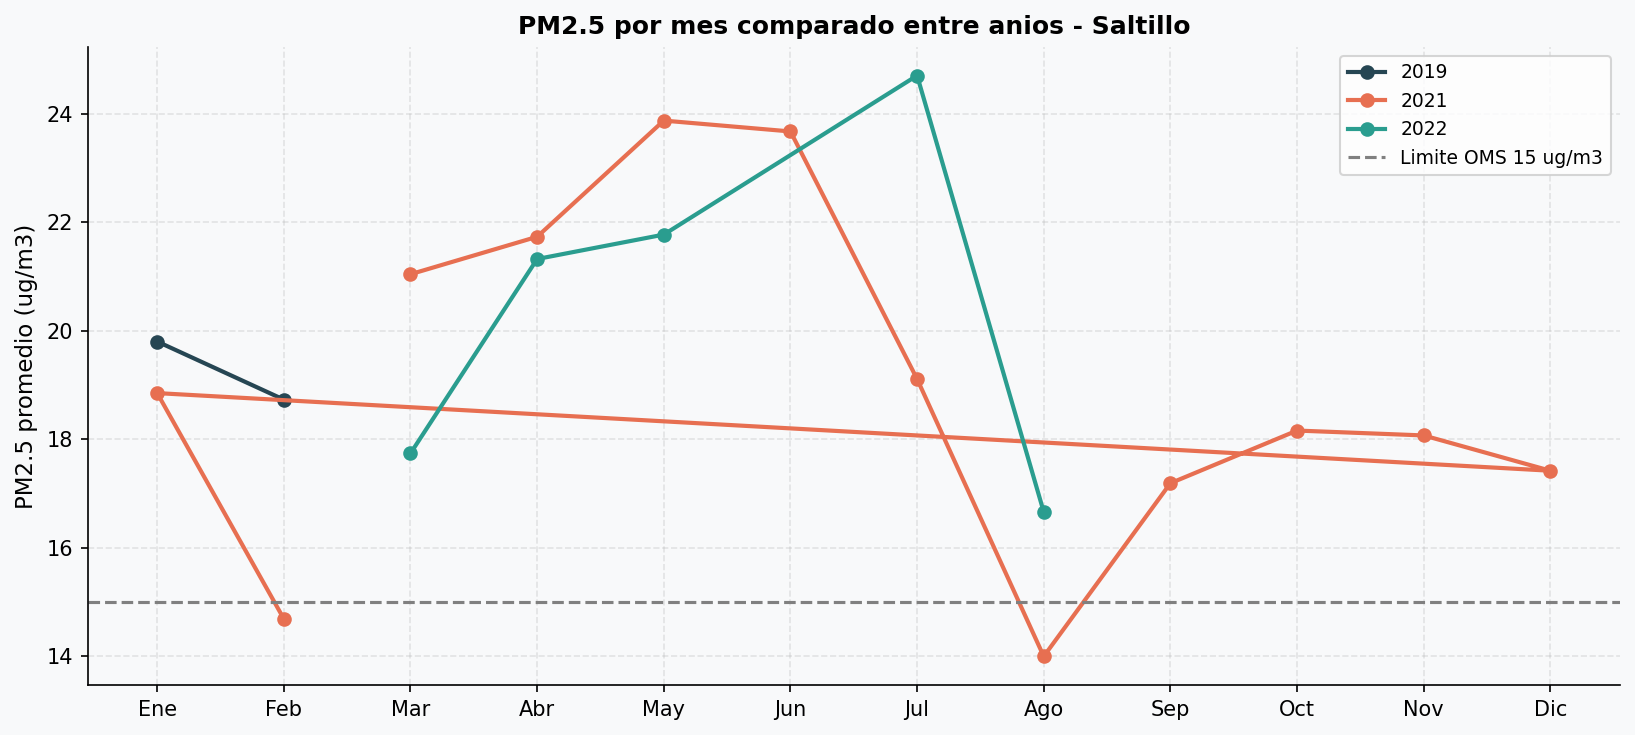

Guardada: grafica0_mes_por_anio.png


In [9]:
# Promedio de PM2.5 por mes y anio
tabla_mes_anio = df.pivot_table(values='PM25', index='mes', columns='anio', aggfunc='mean').round(2)

print('PM2.5 promedio por mes y anio (ug/m3):')
tabla_mes_anio.index = [MESES[m-1] for m in tabla_mes_anio.index]
print(tabla_mes_anio.to_string())

# Grafica: lineas por anio
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(C['fondo'])
ax.set_facecolor(C['fondo'])

colores_anio = ['#264653', '#E76F51', '#2A9D8F', '#E9C46A']
for idx, anio in enumerate(tabla_mes_anio.columns):
    serie = tabla_mes_anio[anio].dropna()
    ax.plot(serie.index, serie.values,
            marker='o', linewidth=2, markersize=6,
            color=colores_anio[idx % len(colores_anio)],
            label=str(anio))

ax.axhline(15, color='gray', linewidth=1.5, linestyle='--', label='Limite OMS 15 ug/m3')
ax.set_xticks(range(len(tabla_mes_anio.index)))
ax.set_xticklabels(tabla_mes_anio.index)
ax.set_ylabel('PM2.5 promedio (ug/m3)', fontsize=11)
ax.set_title('PM2.5 por mes comparado entre anios - Saltillo', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafica0_mes_por_anio.png')
plt.show()
print('Guardada: grafica0_mes_por_anio.png')

## Celda 9 - Grafica 1: Serie de Tiempo
Evolucion mensual de PM2.5 y horas trabajadas en el mismo grafico con doble eje.

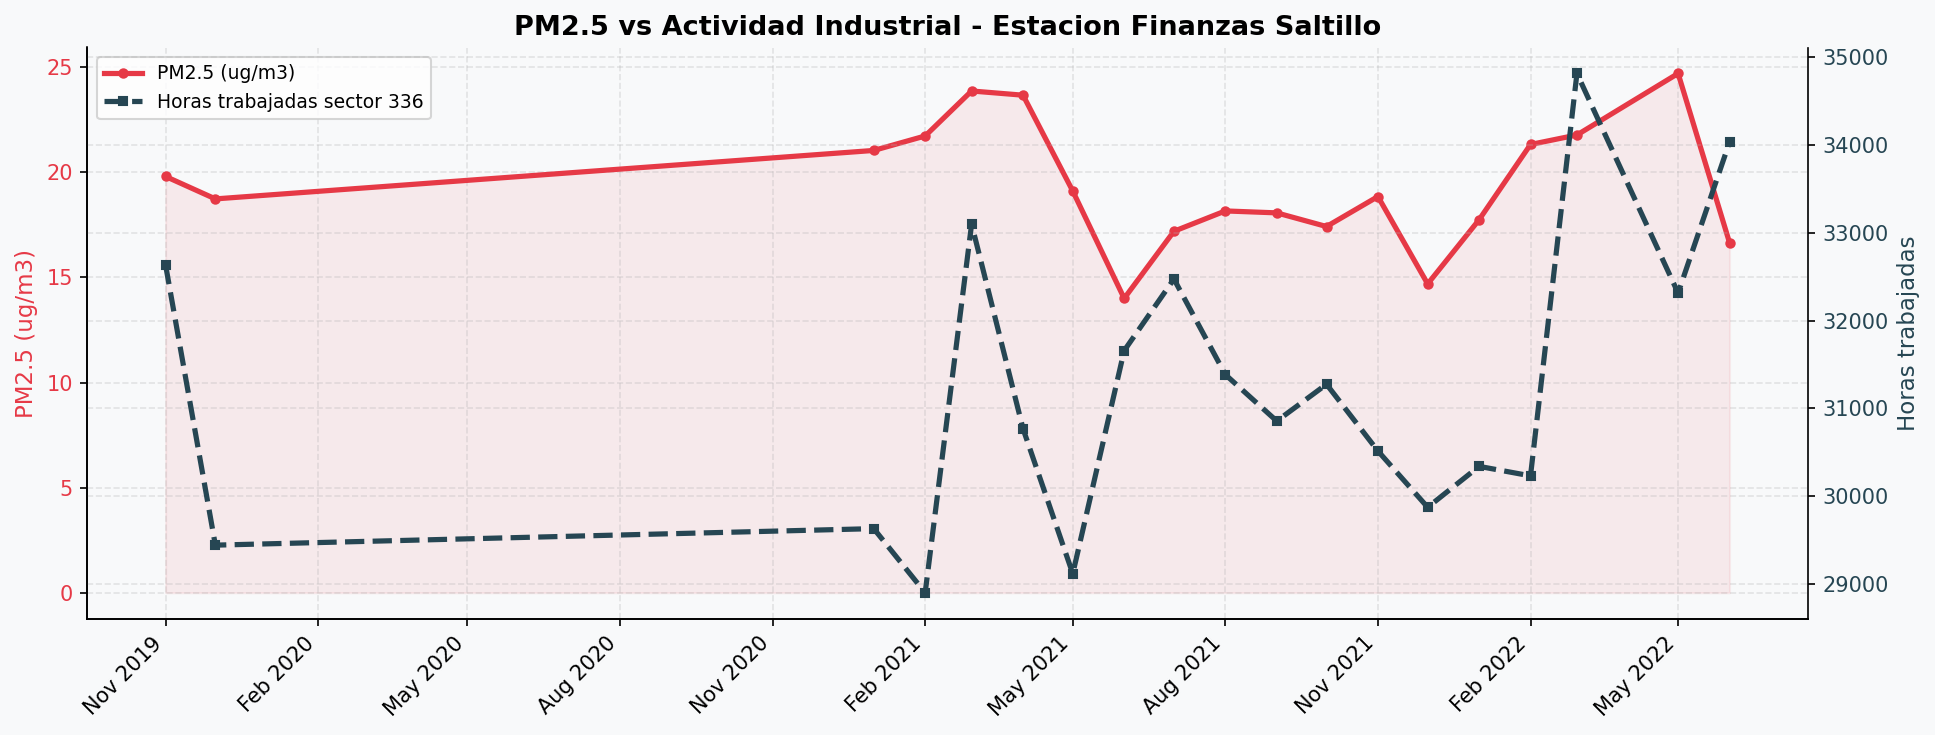

Guardada: grafica1_serie_tiempo.png


In [10]:
fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(C['fondo'])
ax1.set_facecolor(C['fondo'])

ax1.plot(df['fecha'], df['PM25'], color=C['PM25'],
         linewidth=2.5, marker='o', markersize=4, label='PM2.5 (ug/m3)')
ax1.fill_between(df['fecha'], df['PM25'], alpha=0.08, color=C['PM25'])
ax1.set_ylabel('PM2.5 (ug/m3)', color=C['PM25'], fontsize=11)
ax1.tick_params(axis='y', labelcolor=C['PM25'])

ax2 = ax1.twinx()
ax2.plot(df['fecha'], df['horas'], color=C['horas'],
         linewidth=2.5, linestyle='--', marker='s', markersize=4,
         label='Horas trabajadas sector 336')
ax2.set_ylabel('Horas trabajadas', color=C['horas'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=C['horas'])
ax2.spines['right'].set_visible(True)

# Sin salto de linea literal dentro del string
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

l1, n1 = ax1.get_legend_handles_labels()
l2, n2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, n1+n2, loc='upper left', fontsize=9)

ax1.set_title('PM2.5 vs Actividad Industrial - Estacion Finanzas Saltillo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica1_serie_tiempo.png')
plt.show()
print('Guardada: grafica1_serie_tiempo.png')

## Celda 10 - Grafica 2: Mapa de Calor
Correlacion entre todas las variables. Rojo intenso = correlacion positiva fuerte.

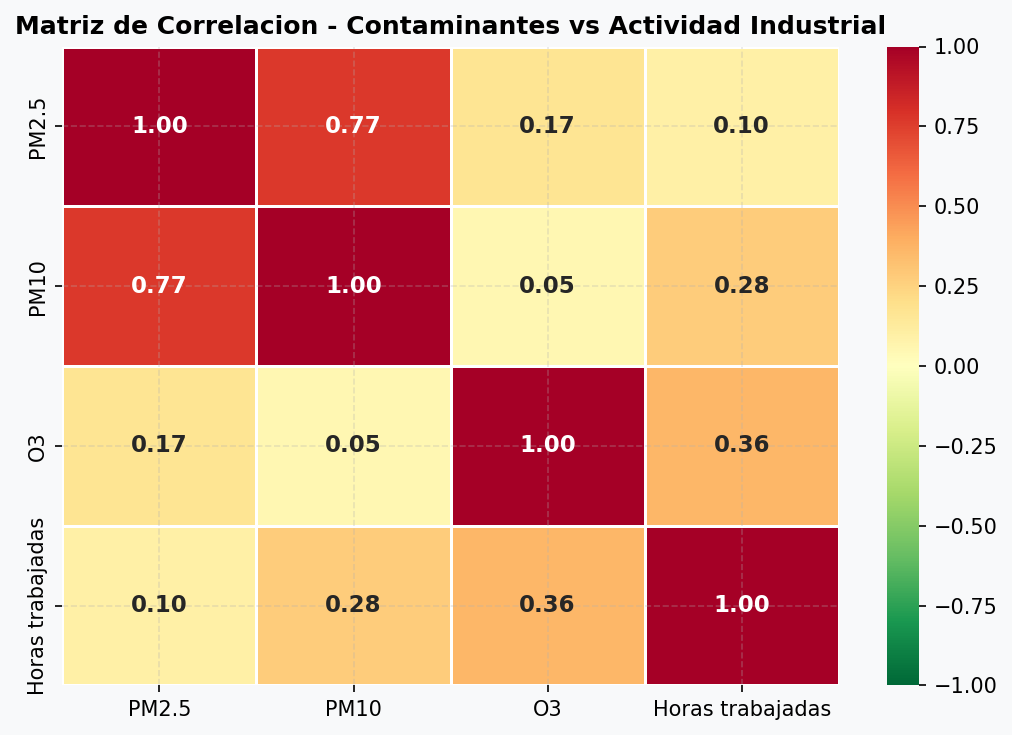

Guardada: grafica2_mapa_calor.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(C['fondo'])
ax.set_facecolor(C['fondo'])

matriz    = df[['PM25', 'PM10', 'O3', 'horas']].corr()
etiquetas = ['PM2.5', 'PM10', 'O3', 'Horas trabajadas']

sns.heatmap(matriz, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            xticklabels=etiquetas, yticklabels=etiquetas,
            annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title('Matriz de Correlacion - Contaminantes vs Actividad Industrial', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafica2_mapa_calor.png')
plt.show()
print('Guardada: grafica2_mapa_calor.png')

## Celda 11 - Grafica 3: Dispersion con Regresion
Cada punto es un mes. La linea muestra la tendencia de la regresion lineal.

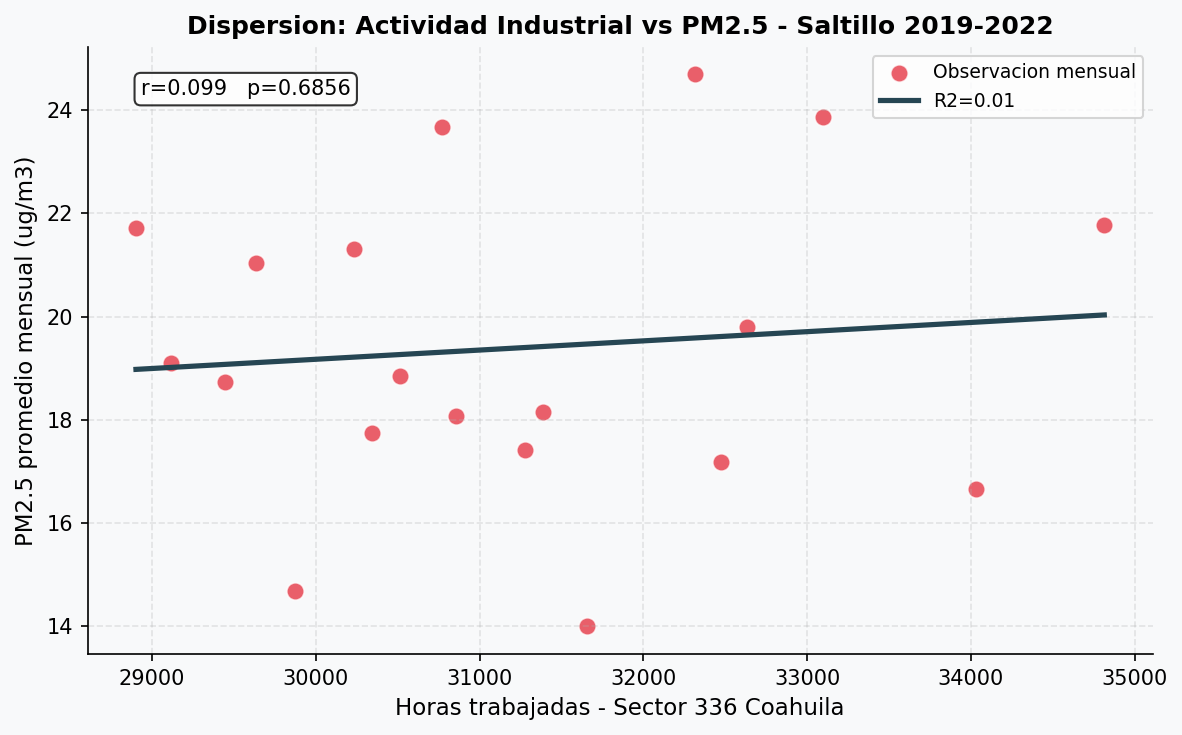

Guardada: grafica3_dispersion.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(C['fondo'])
ax.set_facecolor(C['fondo'])

ax.scatter(df['horas'], df['PM25'], color=C['PM25'],
           alpha=0.8, s=70, edgecolors='white', linewidth=0.8,
           label='Observacion mensual')

x_line = np.linspace(df['horas'].min(), df['horas'].max(), 100).reshape(-1, 1)
ax.plot(x_line, modelo.predict(x_line), color=C['horas'],
        linewidth=2.5, label='R2=' + str(round(r2, 3)))

r_v = resultados['PM25']['r']
p_v = resultados['PM25']['p']
ax.text(0.05, 0.92, 'r=' + str(round(r_v,3)) + '   p=' + str(round(p_v,4)),
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Horas trabajadas - Sector 336 Coahuila', fontsize=11)
ax.set_ylabel('PM2.5 promedio mensual (ug/m3)', fontsize=11)
ax.set_title('Dispersion: Actividad Industrial vs PM2.5 - Saltillo 2019-2022', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafica3_dispersion.png')
plt.show()
print('Guardada: grafica3_dispersion.png')

## Celda 12 - Grafica 4: Comparacion de Correlaciones
Fuerza de la correlacion de horas trabajadas con cada contaminante.

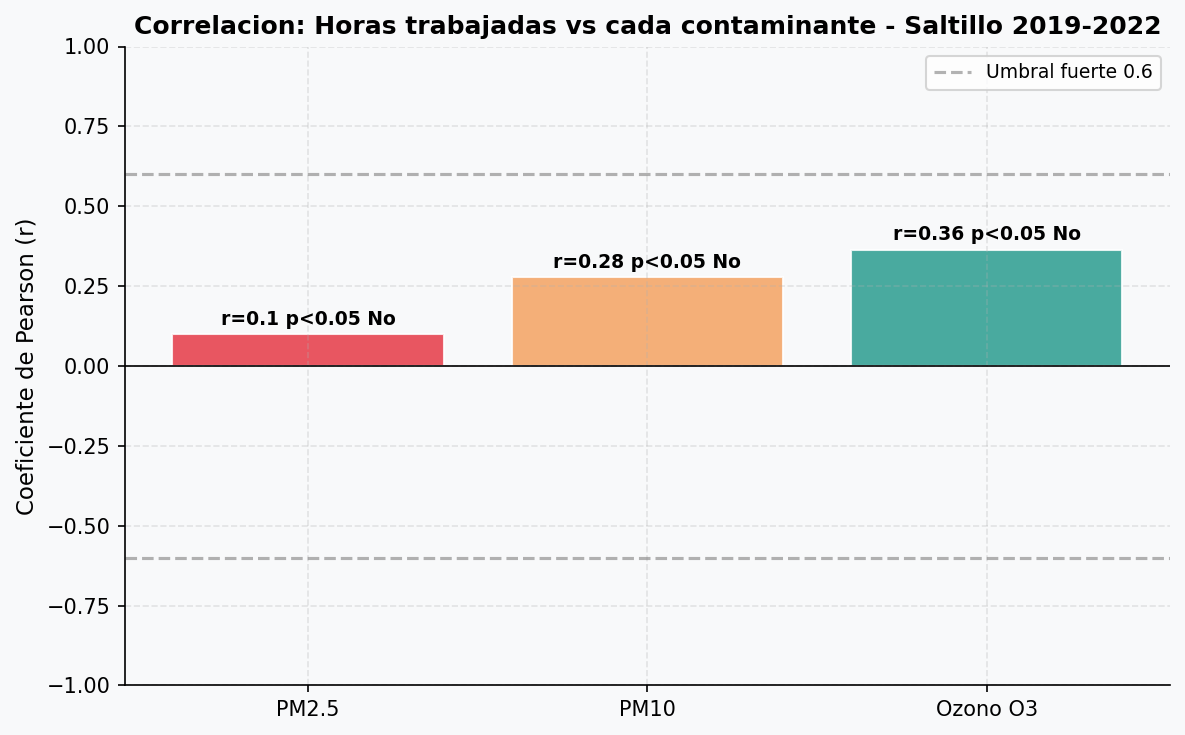

Guardada: grafica4_correlaciones.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(C['fondo'])
ax.set_facecolor(C['fondo'])

nombres   = ['PM2.5', 'PM10', 'Ozono O3']
colores_b = [C['PM25'], C['PM10'], C['O3']]
r_vals    = [resultados[c]['r'] for c in ['PM25', 'PM10', 'O3']]
p_vals    = [resultados[c]['p'] for c in ['PM25', 'PM10', 'O3']]

barras = ax.bar(nombres, r_vals, color=colores_b, alpha=0.85, edgecolor='white')

ax.axhline(0,    color='black', linewidth=0.8)
ax.axhline(0.6,  color='gray', linewidth=1.5, linestyle='--', alpha=0.6, label='Umbral fuerte 0.6')
ax.axhline(-0.6, color='gray', linewidth=1.5, linestyle='--', alpha=0.6)

for barra, r_v, p_v in zip(barras, r_vals, p_vals):
    sig   = 'p<0.05 Si' if p_v < 0.05 else 'p<0.05 No'
    y_pos = r_v + 0.03 if r_v >= 0 else r_v - 0.10
    etiq  = 'r=' + str(round(r_v, 2)) + ' ' + sig
    ax.text(barra.get_x() + barra.get_width()/2, y_pos, etiq,
            ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Coeficiente de Pearson (r)', fontsize=11)
ax.set_ylim(-1, 1)
ax.set_title('Correlacion: Horas trabajadas vs cada contaminante - Saltillo 2019-2022', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafica4_correlaciones.png')
plt.show()
print('Guardada: grafica4_correlaciones.png')

## Celda 13 - Grafica 5: Estacionalidad del PM2.5
Promedio de PM2.5 por mes sobre todo el periodo vs limites OMS.

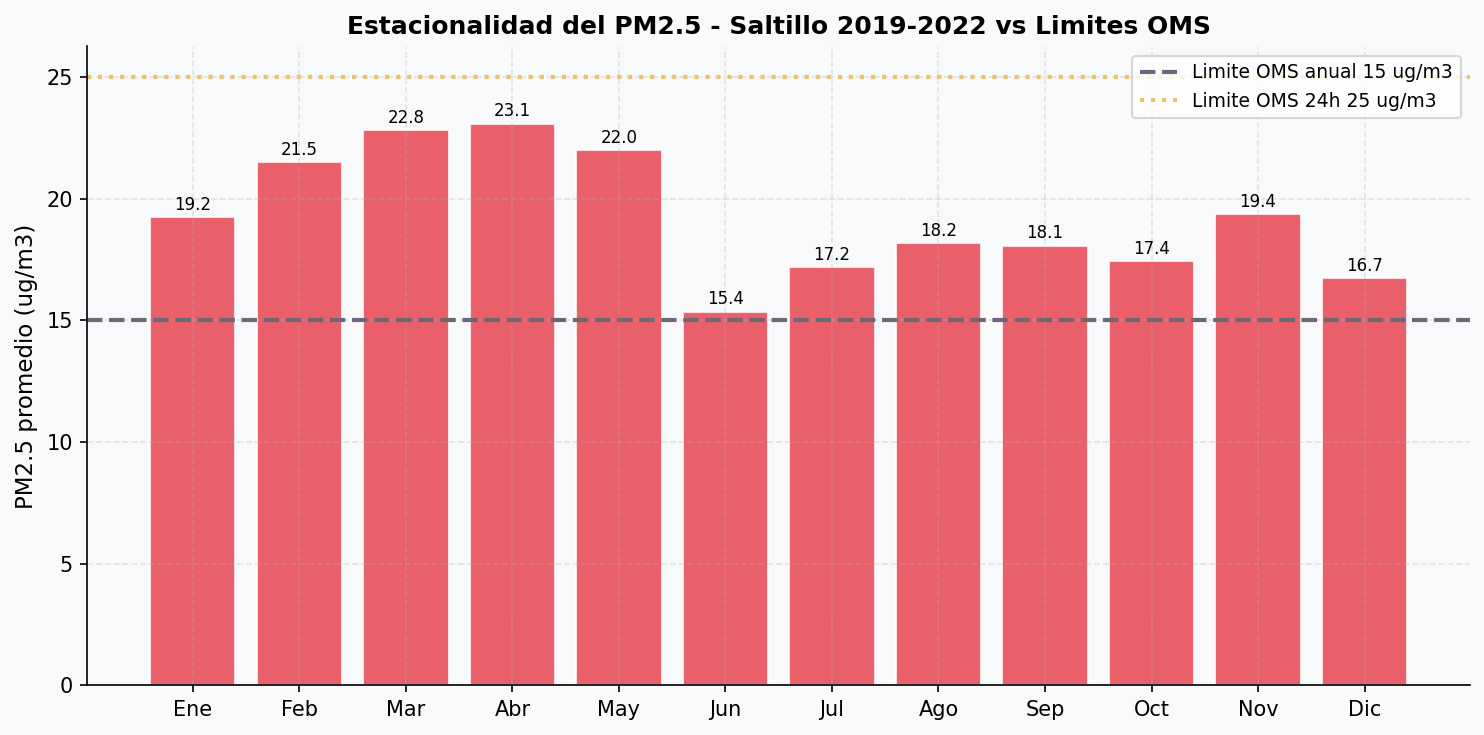

Guardada: grafica5_estacionalidad.png


In [14]:
pm25_fil = pm25_d[
    (pm25_d['fecha'] >= '2019-11-01') &
    (pm25_d['fecha'] <= '2022-06-30')
].copy()
pm25_fil['mes'] = pm25_fil['fecha'].dt.month
por_mes = pm25_fil.groupby('mes')['valor'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C['fondo'])
ax.set_facecolor(C['fondo'])

barras = ax.bar(por_mes.index, por_mes.values, color=C['PM25'], alpha=0.8, edgecolor='white')

ax.axhline(15, color='#6D6875', linewidth=2, linestyle='--', label='Limite OMS anual 15 ug/m3')
ax.axhline(25, color='#E9C46A', linewidth=2, linestyle=':',  label='Limite OMS 24h 25 ug/m3')

ax.set_xticks(por_mes.index)
ax.set_xticklabels([MESES[m-1] for m in por_mes.index])
ax.set_ylabel('PM2.5 promedio (ug/m3)', fontsize=11)
ax.set_title('Estacionalidad del PM2.5 - Saltillo 2019-2022 vs Limites OMS', fontsize=12, fontweight='bold')

for b in barras:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.3, str(round(h,1)), ha='center', fontsize=8)

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafica5_estacionalidad.png')
plt.show()
print('Guardada: grafica5_estacionalidad.png')

## Celda 14 - Resumen Final
Tabla con todos los resultados estadisticos.

In [15]:
print('=' * 65)
print('RESUMEN DE RESULTADOS')
print('=' * 65)
print('Periodo            : Nov 2019 - Jun 2022 (' + str(len(df)) + ' meses)')
print('Estacion SINAICA   : Finanzas, Saltillo')
print('Variable industrial: Horas trabajadas Sector 336 Coahuila EMIM-INEGI')
print()
print(f'{"Correlacion":<22} {"r":>7} {"p-valor":>10} {"Sig":>5} {"Intensidad":>10}')
print('-' * 57)
for cont, v in resultados.items():
    nombre     = 'Horas vs ' + cont
    sig        = 'Si' if v['p'] < 0.05 else 'No'
    intensidad = 'Fuerte' if abs(v['r']) >= 0.7 else 'Moderada' if abs(v['r']) >= 0.4 else 'Debil'
    print(f'{nombre:<22} {v["r"]:>7.3f} {v["p"]:>10.4f} {sig:>5} {intensidad:>10}')
print()
print('Regresion lineal Horas -> PM2.5:')
print('  R2 = ' + str(round(r2,4)) + '  -> explica el ' + str(round(r2*100,1)) + '% de la variacion del PM2.5')
print('  b1 = ' + str(round(float(modelo.coef_[0]),6)))
print('  b0 = ' + str(round(float(modelo.intercept_),4)))
print('=' * 65)

RESUMEN DE RESULTADOS
Periodo            : Nov 2019 - Jun 2022 (19 meses)
Estacion SINAICA   : Finanzas, Saltillo
Variable industrial: Horas trabajadas Sector 336 Coahuila EMIM-INEGI

Correlacion                  r    p-valor   Sig Intensidad
---------------------------------------------------------
Horas vs PM25            0.099     0.6856    No      Debil
Horas vs PM10            0.278     0.2497    No      Debil
Horas vs O3              0.364     0.1260    No      Debil

Regresion lineal Horas -> PM2.5:
  R2 = 0.0099  -> explica el 1.0% de la variacion del PM2.5
  b1 = 0.000178
  b0 = 13.826
